# Deep Learning for NLP

**Deep Learning** is a type of Machine Learning that uses **Neural Networks with multiple layers** to learn patterns from data.

Deep Learning can be used in NLP tasks such as:
- Text Classification
- Sentiment Analysis
- Question Answering

In this lab, we will build a **deep learning model** to classify Yelp restaurant reviews as:

- **0 = Negative**
- **1 = Positive**

<img src="https://drive.google.com/uc?export=view&id=1rUaLO1wEOcUZ10Kwd0nUvS3jQzrqoOcI" width="550">
<img src="https://drive.google.com/uc?export=view&id=1XKPTKwxmIpP5cZIkDajlai6aI9jUX-C8" width="400">

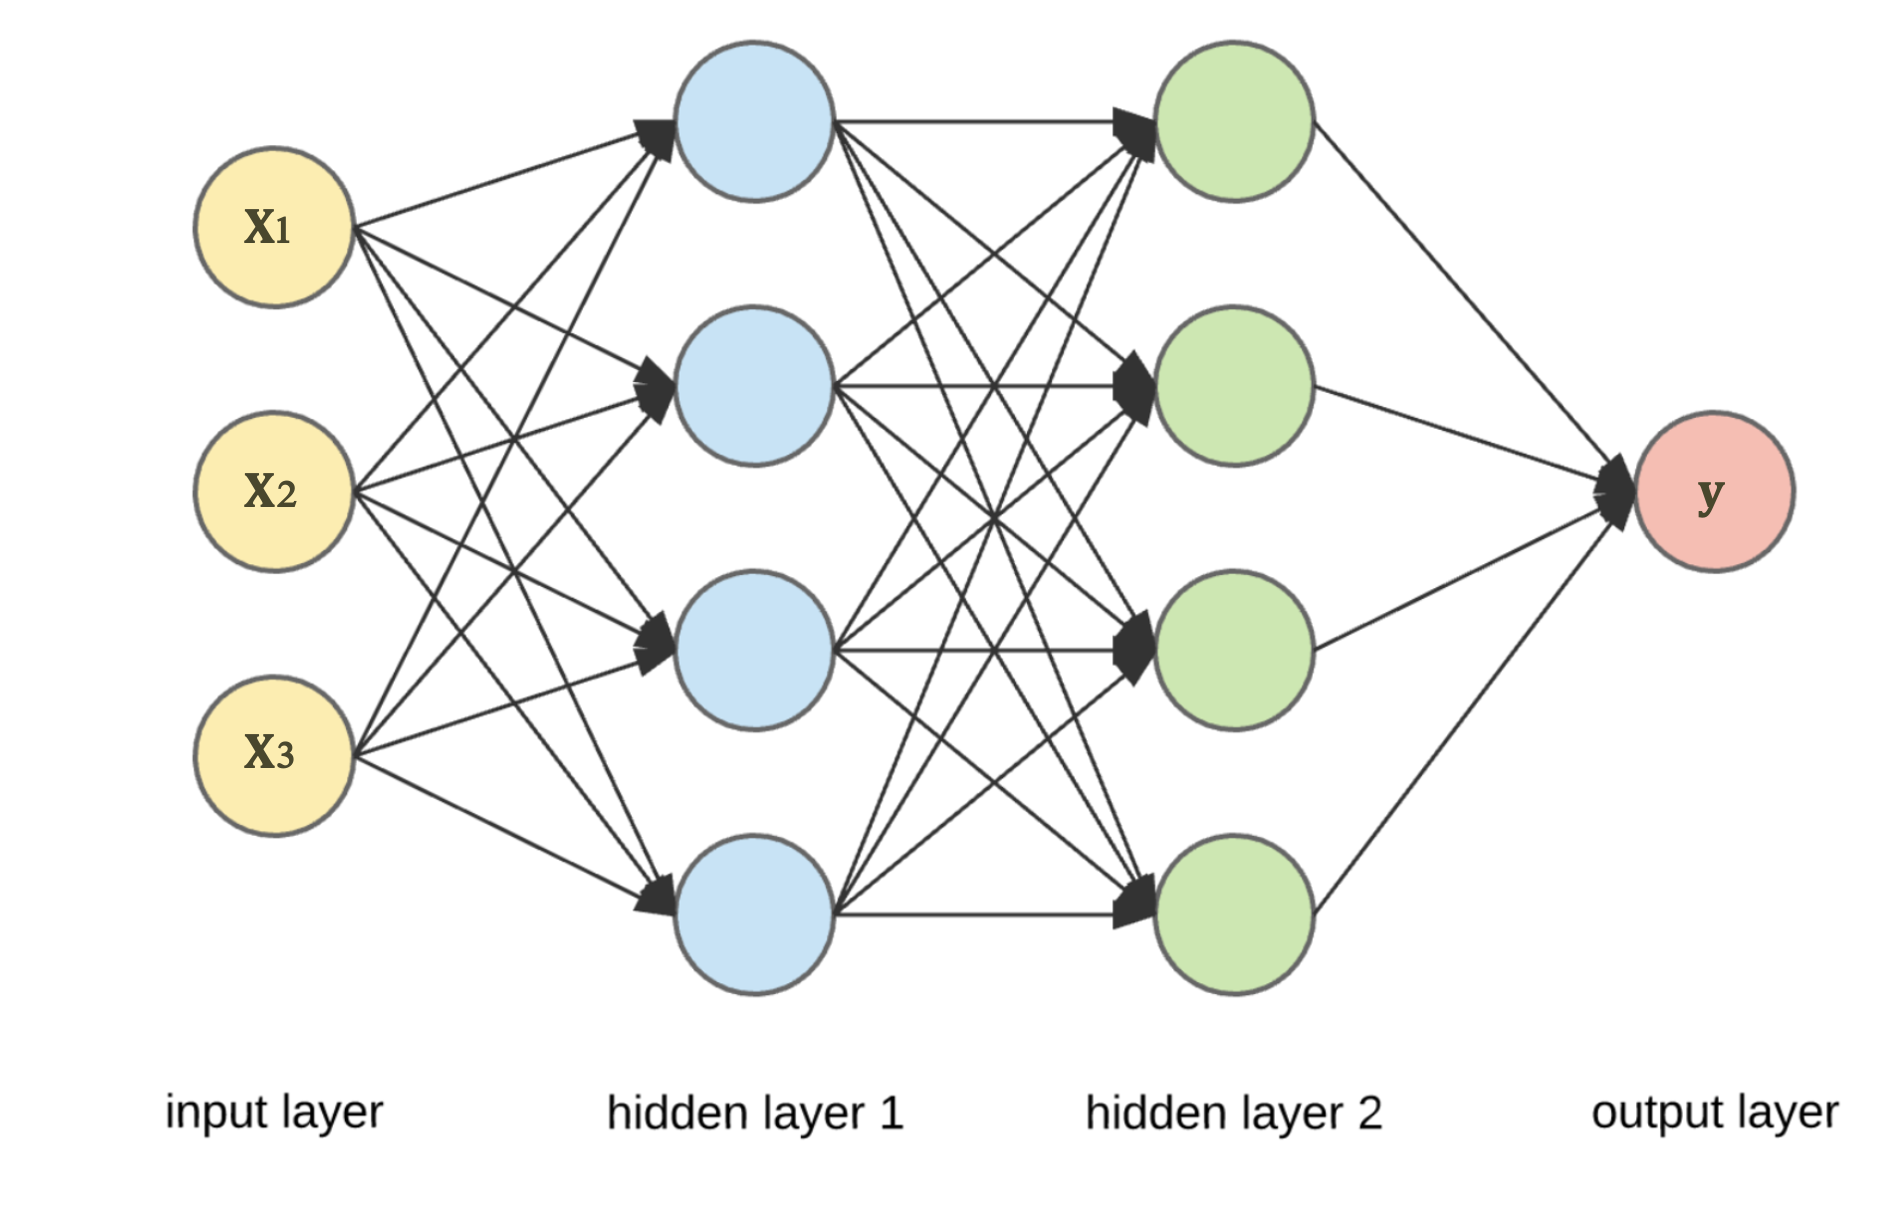
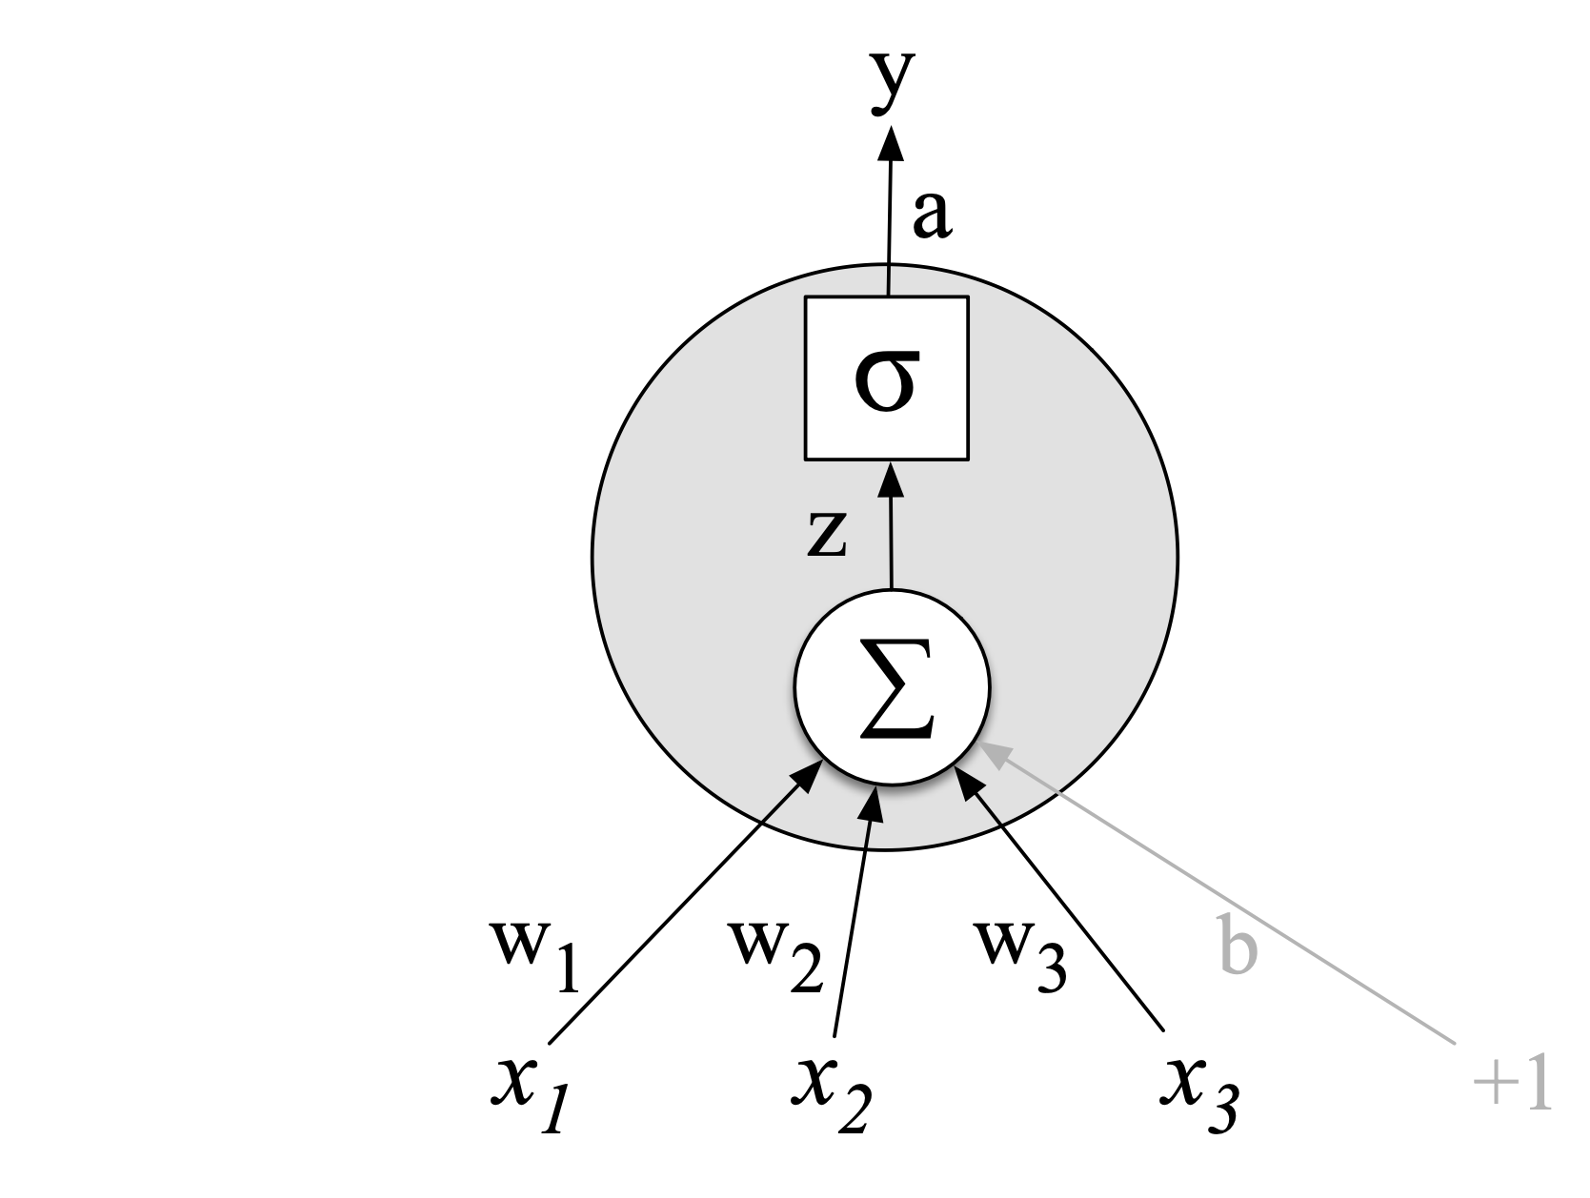

## 1. Load the Yelp Dataset

Each row contains:

- a restaurant review
- its sentiment label


In [45]:
import pandas as pd

df = pd.read_csv("dataset/07-yelp-dataset.txt", sep="\t", names=["review", "label"])

print("Number of reviews:", len(df))
df.head(20)

Number of reviews: 1000


,review,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


In [46]:
print(df["label"].value_counts())

label
1    500
0    500
Name: count, dtype: int64


## 2. Preprocessing the Dataset

In [47]:
import re

def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["review"] = df["review"].apply(preprocess_text)
df.head()

,review,label
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


## 3. Split the Data

We divide the dataset into:

- **80% training data** — used to train the model
- **20% testing data** — used to evaluate the model

`stratify=y` keeps the proportion of positive and negative reviews similar in both sets.

In [48]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 800
Testing reviews: 200


## 4. Convert Text to TF-IDF Vectors

A neural network cannot directly understand text.

**TF-IDF converts each review into a vector of numbers.**


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, lowercase=True) 
# max_features=1000 --> most important 1000 features

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
''' 
* fit_transform --> learns the TF‑IDF vocabulary from 
    the training data then transforms it to vectors

* transform --> uses the already learned vocabulary to 
    transform new (test) data without learning again ( so data leakage wont happened )
'''

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 1000)
Testing TF-IDF shape: (200, 1000)


## 5. Convert the Data to PyTorch Tensors

PyTorch neural networks work with **tensors**.

In [50]:
import torch
import torch.nn as nn

# Convert TF-IDF data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_tfidf.toarray())
X_test_tensor = torch.FloatTensor(X_test_tfidf.toarray())

y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)


# X_train_tfidf is a sparse matrix so we have to convert it to matrix thn to tensors


# sparse matrix: a memory‑efficient matrix format that stores only non‑zero values.
# TF‑IDF outputs sparse matrices because most words don't appear in most documents.

# sparse: means the matrix mostly contains zeros, so sklearn stores only non‑zero values
# to save memory and speed up computations.

## 6. Build a Simple Neural Network

Our network has:

1. **Input layer** — receives the TF-IDF features
2. **Hidden layer** — learns useful patterns
3. **ReLU activation** — adds non-linearity
4. **Output layer** — produces one value for binary classification

We do **not** put `Sigmoid` inside the model because `BCEWithLogitsLoss` applies it internally in a numerically stable way.

In [51]:
input_size = X_train_tensor.shape[1]
# torch.size([800, 1000])

# Sequential --> layer then layer Sequentially || outer model
# linear --> inside each layer is a linear function y=X*w+b
model = nn.Sequential(
    nn.Linear(input_size, 64),   # Input layer || 64 is the neurons number of the input layer
    nn.ReLU(), 

    nn.Linear(64, 32),           # Hidden layer
    nn.ReLU(),

    nn.Linear(32, 1)             # Output layer
)

print(model)

Sequential(
  (0): Linear(in_features=1000, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


## 7. Choose the Loss Function and Optimizer

- **BCEWithLogitsLoss** is used for binary classification.
To measure the model’s mistakes.
- **Adam** is responsible for changing the model's weights so that the loss becomes smaller.

In [52]:
loss_function = nn.BCEWithLogitsLoss() # BCE Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # lr --> learning rate

## 8. Train the Neural Network

One **epoch** means the model has seen the full training dataset once.

For every epoch:

1. Make predictions
2. Calculate the loss
3. Calculate gradients with backpropagation
4. Update the weights

In [53]:
epochs = 10

for epoch in range(epochs):
    model.train() # starts the training

    # 1. Forward pass
    outputs = model(X_train_tensor)

    # 2. Calculate loss
    loss = loss_function(outputs, y_train_tensor)

    # 3. Backpropagation
    loss.backward()

    # 4. Update model weights
    optimizer.step()

    if (epoch + 1) % 5 == 0: # every 5 epoch
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 5/10 - Loss: 0.6591
Epoch 10/10 - Loss: 0.5021


## 9. Evaluate the Model

The model outputs raw scores called **logits**.

We apply `sigmoid` to convert them to probabilities between 0 and 1.

- Probability **≥ 0.5 → Positive (1)**
- Probability **< 0.5 → Negative (0)**

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval() # starts the evaluation

with torch.no_grad():
    test = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test)
    predictions = (test_probabilities >= 0.5).int().numpy().flatten()

accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.775


## 10. Classification Report and Confusion Matrix

The classification report shows:

- **Precision**
- **Recall**
- **F1-score**

The confusion matrix shows how many reviews were classified correctly and incorrectly.

In [55]:
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.81      0.78       100
    Positive       0.80      0.74      0.77       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200

Confusion Matrix:
[[81 19]
 [26 74]]


## Task 1 – Represent Reviews Using Word2Vec

In the previous part of the lab, TF-IDF was used to convert each review into numerical features.
Now, use Word2Vec instead.

Requirements:
Tokenize the training and testing reviews.
Train a Word2Vec model using the training reviews.
Use:
vector_size = 200
window = 5
min_count = 1
sg = 1

Convert each review into a single vector.
Convert the resulting vectors into PyTorch tensors.


In [56]:
# imports
import nltk
import numpy as np
import gensim
from nltk.tokenize import word_tokenize

Tokenize training and testing reviews

In [57]:
train_tokens = [word_tokenize(review) for review in X_train]
test_tokens  = [word_tokenize(review) for review in X_test]

Training

In [58]:
w2v = gensim.models.Word2Vec(train_tokens, min_count=1, vector_size=200, window=5, sg=1)

Convert each review into a single vector

In [59]:
train_vectors = np.array([w2v.wv.get_mean_vector(t) for t in train_tokens])
test_vectors  = np.array([w2v.wv.get_mean_vector(t) for t in test_tokens])

Convert the resulting vectors into PyTorch tensors

In [73]:
import torch

X_train_tensor = torch.FloatTensor(train_vectors)
X_test_tensor  = torch.FloatTensor(test_vectors)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor  = torch.FloatTensor(y_test.values).reshape(-1, 1)

## Task 2 – Build a Different Neural Network

Use the Word2Vec vectors from Task 1 as the input to a new neural network.
Your network must contain:
An input layer
Three hidden layers
ReLU activation functions
One output neuron
Use the following architecture:

Input
   
   ↓

128 neurons
   
   ↓

64 neurons
   
   ↓

32 neurons
   
   ↓

1 output neuron

Train the model using:
, BCEWithLogitsLoss
, Adam optimizer
, Learning rate = 0.001
, 15 epochs.
Then calculate the test accuracy.

In [74]:
input_size = X_train_tensor.shape[1]

# Sequential --> layer then layer Sequentially || outer model
# linear --> inside each layer is a linear function y=X*w+b
model = nn.Sequential(
    nn.Linear(input_size, 128),   # Input layer 
    nn.ReLU(), 

    nn.Linear(128, 64),           # Hidden layer
    nn.ReLU(),

    nn.Linear(64, 32),           # Hidden layer
    nn.ReLU(),

    nn.Linear(32, 1)             # Output layer
)

print(model)

Sequential(
  (0): Linear(in_features=200, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [94]:
loss_function = nn.BCEWithLogitsLoss() # BCE Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # lr --> learning rate

In [95]:
epochs = 15

for epoch in range(epochs):
    model.train() # starts the training

    # 1. Forward pass
    outputs = model(X_train_tensor)

    # 2. Calculate loss
    loss = loss_function(outputs, y_train_tensor)

    # 3. Backpropagation
    loss.backward()

    # 4. Update model weights
    optimizer.step()

    if (epoch + 1) % 5 == 0: # every 5 epoch
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 5/15 - Loss: 0.6955
Epoch 10/15 - Loss: 0.6951
Epoch 15/15 - Loss: 0.6946


As we can see here the model isnt learning enough

In [96]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval() # starts the evaluation

with torch.no_grad():
    test = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test)
    predictions = (test_probabilities >= 0.5).int().numpy().flatten()

accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.500


In [97]:
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       100
    Positive       0.50      1.00      0.67       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200

Confusion Matrix:
[[  0 100]
 [  0 100]]


c:\Users\shaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
